# GameTheory 15f - Valeur de Shapley de groupe : évaluer une équipe, pas une somme d'individus

**Navigation** : [<< 15-CooperativeGames (track principal)](GameTheory-15-CooperativeGames.ipynb) | [Index](README.md) | [15d (Möbius) <<](GameTheory-15d-Mobius-Coalitions.ipynb) | [15e (Pouvoir coalitionnel) <<](GameTheory-15e-Coalition-Power-SMT.ipynb)

**Kernel** : Python 3

**Issue source** : #17531 (distillation de l'Epic #14468)

**Article distillé** : Flores R., Molina E., Tejada J. (2019). *Evaluating groups with the generalized Shapley value*. 4OR 17(2):141-172. doi:[10.1007/s10288-018-0380-8](https://doi.org/10.1007/s10288-018-0380-8)

***

## Introduction

Un décideur doit choisir **k agents** : former un binôme, recruter une équipe, cibler un groupe dans un réseau. Le réflexe est de calculer la valeur de Shapley de chacun et de garder les k meilleurs. Ce réflexe suppose que la valeur d'un groupe est la **somme** des valeurs de ses membres.

Ce notebook montre, calcul exact à l'appui, que cette hypothèse se trompe dès que les agents sont **redondants** (ils apportent la même chose) ou **complémentaires** (l'un rend l'autre utile). Il introduit le bon objet de mesure : la **valeur de Shapley de groupe** $\varphi^g(C)$, qui est la valeur de Shapley généralisée de Marichal, Kojadinovic et Fujimoto (2007), axiomatisée et appliquée à la sélection de groupes par Flores, Molina et Tejada.

| Section | Contenu |
|---|---|
| 1 | Le jeu fusionné de Lehrer, la définition de $\varphi^g$, l'axiome G-SPB face à la valeur additive |
| 2 | L'exemple 1 de l'article, reproduit en arithmétique exacte, et le théorème 2 |
| 3 | Profitabilité d'un groupe et complémentarité moyenne |
| 4 | Transposition au réseau des mariages florentins (Padgett) : calcul exact sur $2^{15}$ coalitions |
| 5 | Estimation Monte Carlo : calibration, puis club de karaté de Zachary ($2^{34}$ coalitions) |

**Prérequis** : GameTheory-15 (valeur de Shapley, axiomes). La décomposition de Möbius de GameTheory-15d éclaire la section 3, sans être indispensable.

**Implémentation** : le module `cooperative_games/group_value.py` du dépôt porte les fonctions utilisées ici ; il est couvert par `tests/test_group_value.py`, qui vérifie les valeurs publiées de l'article et les quatre axiomes.

In [1]:
# Imports et localisation du module cooperative_games (dossier GameTheory).
import sys
import time
from fractions import Fraction
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.stats import spearmanr


def _find_gametheory_dir():
    # Remonte depuis le répertoire courant jusqu'au dossier contenant cooperative_games/.
    search = Path.cwd().resolve()
    for _ in range(10):
        if (search / "cooperative_games").is_dir():
            return search
        if search.parent == search:
            break
        search = search.parent
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        search = Path(nb_file).resolve().parent
        for _ in range(5):
            if (search / "cooperative_games").is_dir():
                return search
            search = search.parent
    raise ImportError("Dossier cooperative_games introuvable : lancer le notebook depuis MyIA.AI.Notebooks/GameTheory.")


sys.path.insert(0, str(_find_gametheory_dir()))

from cooperative_games import (
    CoalitionGame,
    GroupValueTable,
    additive_group_value,
    connectivity_game,
    merging_game,
    shapley_group_value,
    shapley_group_value_monte_carlo,
    shapley_value_formula,
)

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | networkx {nx.__version__}")
print("Module cooperative_games.group_value chargé.")

Python 3.13.14 | numpy 2.4.4 | networkx 3.6.1
Module cooperative_games.group_value chargé.


## 1. Du joueur au groupe : le jeu fusionné

### 1.1 Définition

Soit un jeu coopératif $(N, v)$ à $n$ joueurs et un groupe $C \subseteq N$ de $c$ joueurs qui s'engagent à agir comme **une seule unité**. Lehrer (1988) remplace le groupe par un **mandataire** unique, noté $c$, et définit le **jeu fusionné** $(N_C, v_C)$ sur $N_C = (N \setminus C) \cup \{c\}$ :

- si le mandataire n'est pas dans $S$, alors $v_C(S) = v(S)$ ;
- si le mandataire est dans $S$, alors $v_C(S) = v\big((S \setminus \{c\}) \cup C\big)$.

La **valeur de Shapley de groupe** est la valeur de Shapley du mandataire dans ce jeu fusionné (définition 2 de l'article) :

$$\varphi^g(C) \;=\; \varphi_c(N_C, v_C) \;=\; \sum_{T \subseteq N \setminus C} \frac{t!\,(m-t-1)!}{m!}\,\big(v(T \cup C) - v(T)\big), \qquad m = n - c + 1.$$

La différence avec la valeur additive $\sum_{i \in C} \varphi_i$ est dans le **nombre d'acteurs** : le groupe arrive en bloc dans un ordre aléatoire de $m$ acteurs, pas de $n$. Il ne compte qu'une fois, et ses membres ne peuvent plus se « voler » mutuellement leurs contributions marginales.

Le code ci-dessous construit le graphe de l'exemple 1 de l'article (neuf sommets, numérotés de 1 à 9 comme dans le texte), le jeu de connectivité d'Amer et Gimenez (2004), $v(S) = 1$ si $S$ induit un sous-graphe connexe avec au moins deux sommets et $0$ sinon, puis le jeu fusionné du groupe $\{4, 5\}$.

In [2]:
# Code 1.1 - Jeu de connectivité de l'exemple 1 et jeu fusionné d'un groupe.
EXAMPLE1_EDGES = [(1, 4), (2, 4), (3, 4), (4, 5), (5, 6), (6, 7), (6, 8), (6, 9)]
LABELS = [str(k) for k in range(1, 10)]          # le sommet k de l'article a l'indice k-1


def idx(*nodes):
    # Indices 0-based des sommets de l'article.
    return [k - 1 for k in nodes]


ex1 = connectivity_game(9, [(a - 1, b - 1) for a, b in EXAMPLE1_EDGES], LABELS)

merged, mapping = merging_game(ex1, idx(4, 5))
print("Joueurs du jeu fusionné N_C :", merged.player_names)
print(f"n = {ex1.n_players} joueurs  ->  m = {merged.n_players} acteurs après fusion de {{4, 5}}")

proxy = merged.n_players - 1
position = {nom: k for k, nom in enumerate(merged.player_names)}   # nom -> indice dans N_C
for noms in (["{4, 5}"], ["{4, 5}", "6"], ["{4, 5}", "7"], ["7", "8"], ["6", "7"]):
    print(f"  v_C({', '.join(noms)}) = {merged.value({position[x] for x in noms})}")

phi_proxy = Fraction(shapley_value_formula(merged)[proxy]).limit_denominator(10_000)
phi_g = shapley_group_value(ex1, idx(4, 5), exact=True)
print(f"\nShapley du mandataire dans (N_C, v_C) : {phi_proxy}")
print(f"phi_g({{4, 5}}) par la formule directe   : {phi_g}")

Joueurs du jeu fusionné N_C : ['1', '2', '3', '6', '7', '8', '9', '{4, 5}']
n = 9 joueurs  ->  m = 8 acteurs après fusion de {4, 5}
  v_C({4, 5}) = 1
  v_C({4, 5}, 6) = 1
  v_C({4, 5}, 7) = 0
  v_C(7, 8) = 0
  v_C(6, 7) = 1

Shapley du mandataire dans (N_C, v_C) : 187/280
phi_g({4, 5}) par la formule directe   : 187/280


### Lecture du résultat : le mandataire porte la valeur du groupe

Le jeu fusionné n'a plus que $m = 8$ acteurs : les sept sommets hors du groupe et le mandataire `{4, 5}`. Les cinq évaluations se lisent directement sur le graphe d'origine. Seul, le mandataire vaut 1, car l'arête 4-5 rend le groupe connexe. Avec le sommet 6, il vaut encore 1 (la chaîne 4-5-6). Avec le sommet 7, il vaut 0 : 7 n'est relié à 5 que par 6, absent de la coalition. Hors du groupe, la paire $\{7, 8\}$ vaut 0 (deux feuilles sans leur centre) et la paire $\{6, 7\}$ vaut 1 (une arête).

Les deux calculs de la dernière ligne, la valeur de Shapley du mandataire obtenue par le module `shapley.py` et la formule directe en fractions, donnent **la même fraction, 187/280**. C'est exactement la valeur publiée par Flores, Molina et Tejada pour ce groupe. La définition 2 n'est donc pas une nouvelle formule mais une **réduction** : évaluer un groupe revient à évaluer un joueur dans un autre jeu.

### 1.2 Pourquoi pas la somme des valeurs individuelles ? L'axiome G-SPB

Le théorème 1 de l'article caractérise $\varphi^g$ comme l'**unique** valeur de groupe qui vérifie quatre propriétés :

| Axiome | Énoncé |
|---|---|
| G-joueur nul | ajouter un joueur nul à un groupe ne change pas sa valeur |
| G-linéarité | la valeur de groupe est linéaire en $v$ |
| G-contributions équilibrées (G-CBC) | l'effet de la présence de $j$ sur l'apport de $i$ au groupe est égal à l'effet de la présence de $i$ sur l'apport de $j$ |
| G-SPB (symétrie dans le marchandage pur) | dans le jeu d'unanimité de la grande coalition $u_N$, tout groupe vaut $1/(n-c+1)$ |

La remarque 2 de l'article montre que si l'on remplace G-SPB par « tout groupe vaut $c/n$ dans $u_N$ », les trois autres axiomes caractérisent la **valeur additive** $\sum_{i \in C} \varphi_i$. Toute la différence entre les deux notions tient donc dans une seule question : dans un marchandage où chacun est indispensable, un groupe de $c$ personnes pèse-t-il comme **une voix** ou comme **$c$ voix** ?

In [3]:
# Code 1.2 - G-SPB contre valeur additive dans le jeu d'unanimité u_N (n = 6).
n = 6
unanimite = CoalitionGame(n, lambda s: 1 if len(s) == n else 0)

print(f"{'c':>2}  {'phi_g(C)':>9}  {'1/(n-c+1)':>9}  {'additive':>9}  {'c/n':>6}")
for c in range(1, n + 1):
    groupe = set(range(c))
    g = shapley_group_value(unanimite, groupe, exact=True)
    a = additive_group_value(unanimite, groupe, exact=True)
    print(f"{c:>2}  {str(g):>9}  {str(Fraction(1, n - c + 1)):>9}  {str(a):>9}  {str(Fraction(c, n)):>6}")

 c   phi_g(C)  1/(n-c+1)   additive     c/n
 1        1/6        1/6        1/6     1/6
 2        1/5        1/5        1/3     1/3
 3        1/4        1/4        1/2     1/2
 4        1/3        1/3        2/3     2/3
 5        1/2        1/2        5/6     5/6
 6          1          1          1       1


### Lecture du résultat : une voix, pas c voix

Pour $c = 1$, les deux notions coïncident (1/6) : un groupe d'une personne est cette personne. Elles divergent aussitôt ensuite. Un groupe de trois joueurs sur six vaut **1/4** au sens de $\varphi^g$ et **1/2** au sens additif : fusionné, il négocie comme un seul acteur face aux trois autres, soit quatre acteurs indispensables à parts égales. Pour $c = 6$, le groupe est la grande coalition et vaut 1 dans les deux cas.

Ce n'est pas un défaut de la valeur additive : elle répond à une autre question (« combien reçoivent au total les membres, pris un par un ? »). Mais quand la question est « que vaut ce groupe **en tant qu'unité** ? », seul $\varphi^g$ tient compte de ce que la fusion retire aux membres : la possibilité de se disputer la même contribution marginale.

### Exercice 1 - Unanimité d'une coalition partielle

Dans le jeu d'unanimité $u_S$ (valeur 1 si et seulement si la coalition contient $S$), la valeur de Shapley individuelle vaut $1/s$ pour chaque membre de $S$ et 0 ailleurs. On cherche la formule de $\varphi^g(C; u_S)$ pour un groupe $C$ quelconque.

- **Étape 1** : avec $n = 7$ et $S = \{0, 1, 2, 3\}$, calculer $\varphi^g(C)$ en fractions exactes pour tous les groupes $C$ de taille 1 à 3.
- **Étape 2** : regrouper les résultats selon $\lvert C \cap S \rvert$ et $\lvert S \setminus C \rvert$.
- **Étape 3** : conjecturer une formule fermée, puis la tester sur $n = 8$ et $S = \{0, 2, 4\}$.

*Indice* : que vaut $v_C$ quand le groupe ne touche pas $S$ ? Combien d'acteurs indispensables restent-ils quand il le touche ?

In [4]:
# Exercice 1 : valeur de groupe dans u_S et formule fermée.
# TODO étudiant : construire u_S avec CoalitionGame, puis calculer
# shapley_group_value(..., exact=True) pour tous les groupes de taille 1 à 3.

resultats = None  # TODO étudiant : dict {groupe: fraction}
formule_conjecturee = None  # TODO étudiant : fonction (C, S) -> Fraction

print("Exercice 1 à compléter : valeur de groupe dans le jeu d'unanimité u_S.")

Exercice 1 à compléter : valeur de groupe dans le jeu d'unanimité u_S.


## 2. L'exemple 1 de l'article, en arithmétique exacte

### 2.1 Le meilleur binôme n'est pas celui des deux meilleurs individus

Le graphe de l'exemple 1 est une « double étoile » : les feuilles 1, 2, 3 pendent au centre 4, les feuilles 7, 8, 9 au centre 6, et le sommet 5 relie les deux centres. Le code trace ce graphe, calcule les neuf valeurs individuelles en fractions exactes, puis classe les 36 binômes par valeur de groupe.

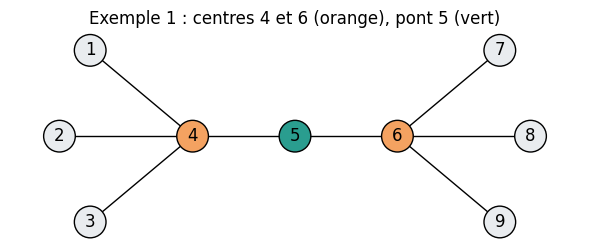

360 * phi_i : [-8, -8, -8, 139, 130, 139, -8, -8, -8]

rang    binôme       phi_g   additive
   1    (4, 5)     187/280     0.7472
   2    (5, 6)     187/280     0.7472
   3    (4, 6)         1/2     0.7722
   4    (1, 4)     131/280     0.3639
   5    (2, 4)     131/280     0.3639

Binôme des deux meilleurs individus (4, 6) : phi_g = 1/2, rang 3 sur 36


In [5]:
# Code 2.1 - Valeurs individuelles et classement exact des 36 binômes de l'exemple 1.
g1 = nx.Graph(EXAMPLE1_EDGES)
pos = {1: (-2, 1), 2: (-2.3, 0), 3: (-2, -1), 4: (-1, 0), 5: (0, 0), 6: (1, 0), 7: (2, 1), 8: (2.3, 0), 9: (2, -1)}
fig, ax = plt.subplots(figsize=(6, 2.6))
nx.draw_networkx(g1, pos, ax=ax, node_color=["#f4a261" if k in (4, 6) else "#2a9d8f" if k == 5 else "#e9ecef" for k in g1.nodes()],
                 node_size=520, edgecolors="black")
ax.set_title("Exemple 1 : centres 4 et 6 (orange), pont 5 (vert)")
ax.axis("off")
plt.tight_layout()
plt.show()

phi_exact = [shapley_group_value(ex1, [i], exact=True) for i in range(9)]
print("360 * phi_i :", [int(p * 360) for p in phi_exact])

binomes = []
for a, b in combinations(range(9), 2):
    binomes.append(((a + 1, b + 1), shapley_group_value(ex1, [a, b], exact=True), phi_exact[a] + phi_exact[b]))
binomes.sort(key=lambda r: (-r[1], r[0]))

print(f"\n{'rang':>4}  {'binôme':>8}  {'phi_g':>10}  {'additive':>9}")
for rang, (paire, g, a) in enumerate(binomes[:5], start=1):
    print(f"{rang:>4}  {str(paire):>8}  {str(g):>10}  {float(a):9.4f}")
rang_46 = [r[0] for r in binomes].index((4, 6)) + 1
print(f"\nBinôme des deux meilleurs individus (4, 6) : phi_g = {shapley_group_value(ex1, idx(4, 6), exact=True)}, rang {rang_46} sur 36")

### Lecture du résultat : reproduction exacte, et un classement qui s'inverse

Les valeurs individuelles reproduisent **exactement** celles de l'article : $360\,\varphi_i = -8$ pour les six feuilles, $139$ pour les centres 4 et 6, $130$ pour le pont 5. Les feuilles ont une valeur négative : ajoutée à un centre isolé, une feuille crée une paire connexe (+1), mais ajoutée à une coalition connexe qui ne contient pas son centre, elle la déconnecte.

Au classement individuel, le meilleur binôme serait $\{4, 6\}$ (valeur additive $278/360 \approx 0.772$). Au classement par valeur de groupe, il vaut **1/2** et n'arrive qu'au troisième rang (dernière ligne), derrière les binômes centre + pont $\{4, 5\}$ et $\{5, 6\}$ qui valent **187/280**, là encore la valeur publiée. Les deux centres sont redondants : aucun ne rend l'autre plus utile, puisqu'ils ne sont pas adjacents et qu'il faut le pont 5 pour les relier.

### 2.2 Le théorème 2 : indépendance plus complémentarité

La **complémentarité moyenne** de deux joueurs (définition 3) moyenne leur différence d'ordre 2, qui mesure combien la présence de $i$ augmente l'apport de $j$ :

$$\psi_{ij}(N, v) = \sum_{S \subseteq N \setminus \{i,j\}} \frac{s!\,(n-s-1)!}{n!}\,\Delta^2_{ij}(S), \qquad \Delta^2_{ij}(S) = v(S \cup \{i,j\}) - v(S \cup \{i\}) - v(S \cup \{j\}) + v(S).$$

Le **théorème 2** décompose l'apport d'un nouveau membre $i$ à un groupe $C$ en deux termes :

$$\varphi^g(C \cup \{i\}) - \varphi^g(C) = \underbrace{\varphi_i(N \setminus C,\, v_{\vert N \setminus C})}_{\text{valeur de } i \text{ sans le groupe}} + \underbrace{\psi_{ci}(N_C, v_C)}_{\text{complémentarité avec le groupe}}.$$

Le code vérifie cette décomposition sur les deux binômes de l'exemple, avec le centre 4 comme membre initial.

In [6]:
# Code 2.2 - Décomposition du théorème 2 sur l'exemple 1 (groupe initial C = {4}).
t1 = GroupValueTable(ex1)


def frac(x):
    return Fraction(x).limit_denominator(10_000)


print(f"{'binôme':>7}  {'phi_4':>7}  {'phi_j(N-4)':>10}  {'psi_4j':>7}  {'somme':>7}  {'phi_g':>7}")
for j in (6, 5):
    phi4 = t1.shapley()[idx(4)[0]]
    indep = t1.restricted_shapley(idx(j)[0], idx(4))
    compl = t1.complementarity(idx(4)[0], idx(j)[0])
    total = phi4 + indep + compl
    print(f"  (4, {j})  {str(frac(phi4)):>7}  {str(frac(indep)):>10}  {str(frac(compl)):>7}  {str(frac(total)):>7}  {str(frac(t1.group_value(idx(4, j)))):>7}")

 binôme    phi_4  phi_j(N-4)   psi_4j    somme    phi_g
  (4, 6)  139/360         1/8    -1/90      1/2      1/2
  (4, 5)  139/360        1/56    19/72  187/280  187/280


### Lecture du résultat : le pont gagne par la complémentarité

Les deux lignes reproduisent les calculs de l'article au terme près : pour le binôme $\{4, 6\}$, $139/360 + 1/8 - 1/90 = 1/2$ ; pour $\{4, 5\}$, $139/360 + 1/56 + 19/72 = 187/280$.

La lecture est instructive. **Sans le centre 4**, le centre 6 vaut encore $1/8$ (il reste le cœur de sa propre étoile) alors que le pont 5 ne vaut plus que $1/56$ : pris isolément, 6 est un bien meilleur renfort. Mais leur **complémentarité** avec 4 est de signe opposé : $\psi_{46} = -1/90$ (les deux centres se font légèrement concurrence), $\psi_{45} = 19/72$ (le pont rend le centre 4 beaucoup plus utile, puisqu'il lui ouvre l'autre moitié du graphe). La complémentarité l'emporte largement sur l'indépendance. C'est exactement l'information que la valeur additive jette.

## 3. Profitabilité et complémentarité

La section 4 de l'article appelle **profitabilité** d'un groupe l'écart entre sa valeur en tant qu'unité et la somme des valeurs de ses membres :

$$P(C) = \varphi^g(C) - \sum_{i \in C} \varphi_i.$$

Un groupe profitable ($P(C) > 0$) gagne à s'intégrer ; un groupe non profitable y perd. Derks et Tijs (2000) et Segal (2003) donnent des conditions suffisantes (portant sur les dividendes de Harsanyi, ou sur le signe des différences d'ordre 3). Le code calcule la matrice des $\psi_{ij}$ et la profitabilité des 36 binômes de l'exemple 1, en séparant les binômes adjacents dans le graphe des autres.

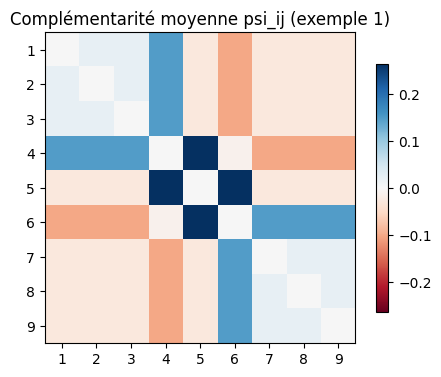

psi max = 0.2639 pour la paire (4, 5)
psi min = -0.1028 pour la paire (1, 6)
psi sur les 8 arêtes : min 0.1472 ; binômes non adjacents à psi < 0 : 22 sur 28
Profitabilité des  8 binômes adjacents     : moyenne +0.0581, min -0.0794, max +0.1040, profitables 6/8
Profitabilité des 28 binômes non adjacents : moyenne -0.0345, min -0.2722, max -0.0032, profitables 0/28
Profitabilité du meilleur binôme (4, 5) : -0.0794 ; d'un binôme feuille + centre (1, 4) : +0.1040


In [7]:
# Code 3.1 - Matrice de complémentarité et profitabilité des binômes de l'exemple 1.
psi = np.zeros((9, 9))
for a, b in combinations(range(9), 2):
    psi[a, b] = psi[b, a] = t1.complementarity(a, b)

phi1 = t1.shapley()
adjacent, non_adjacent = [], []
for a, b in combinations(range(9), 2):
    p = t1.profitability([a, b], phi1)
    (adjacent if g1.has_edge(a + 1, b + 1) else non_adjacent).append(p)

fig, ax = plt.subplots(figsize=(4.6, 3.8))
lim = np.abs(psi).max()
im = ax.imshow(psi, cmap="RdBu", vmin=-lim, vmax=lim)
ax.set_xticks(range(9), LABELS)
ax.set_yticks(range(9), LABELS)
ax.set_title("Complémentarité moyenne psi_ij (exemple 1)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"psi max = {psi.max():.4f} pour la paire {tuple(int(k) + 1 for k in np.unravel_index(psi.argmax(), psi.shape))}")
print(f"psi min = {psi.min():.4f} pour la paire {tuple(int(k) + 1 for k in np.unravel_index(psi.argmin(), psi.shape))}")
psi_aretes = [psi[a - 1, b - 1] for a, b in EXAMPLE1_EDGES]
print(f"psi sur les {len(psi_aretes)} arêtes : min {min(psi_aretes):.4f} ; binômes non adjacents à psi < 0 : "
      f"{sum(psi[a, b] < 0 for a, b in combinations(range(9), 2) if not g1.has_edge(a + 1, b + 1))} sur {len(non_adjacent)}")
for nom, groupe in (("adjacents", adjacent), ("non adjacents", non_adjacent)):
    print(f"Profitabilité des {len(groupe):>2} binômes {nom:<13} : moyenne {np.mean(groupe):+.4f}, min {min(groupe):+.4f}, "
          f"max {max(groupe):+.4f}, profitables {sum(p > 0 for p in groupe)}/{len(groupe)}")
print(f"Profitabilité du meilleur binôme (4, 5) : {t1.profitability(idx(4, 5), phi1):+.4f} ; d'un binôme feuille + centre (1, 4) : "
      f"{t1.profitability(idx(1, 4), phi1):+.4f}")

### Lecture du résultat : le binôme le plus précieux n'est pas profitable

La matrice $\psi$ suit le graphe. Les huit arêtes ont toutes une complémentarité positive, et les deux plus fortes ($19/72 \approx 0.264$) relient le pont 5 aux deux centres. À l'inverse, 22 des 28 binômes non adjacents ont une complémentarité négative ; la plus négative, $(1, 6)$, associe une feuille d'une étoile au centre de l'autre, qui ne peuvent appartenir à une même composante connexe sans 4 et 5. Les six exceptions positives, faibles ($0.022$), sont des feuilles sœurs : elles profitent toutes deux de la présence de leur centre commun.

La profitabilité raconte une autre histoire. Les 28 binômes non adjacents sont tous non profitables : fusionner deux joueurs éloignés leur retire plus qu'il ne leur apporte. Parmi les huit binômes adjacents, six sont profitables, les couples feuille + centre ($+0.104$). Les deux exceptions sont **précisément les deux meilleurs binômes** de la section 2, centre + pont, à $-0.079$ : le groupe le plus précieux perd à s'intégrer, parce que ses deux membres valaient déjà beaucoup séparément. La valeur d'un groupe, sa complémentarité interne et sa profitabilité sont trois grandeurs distinctes. C'est la leçon de Segal (2003), reprise par l'article, et c'est pourquoi un décideur qui veut **le meilleur groupe** doit classer par $\varphi^g$, pas par profitabilité.

### Exercice 2 - Vérifier le théorème 2 sur un groupe de taille 2

Le code 2.2 vérifie le théorème 2 pour un groupe initial d'un seul joueur. On le vérifie maintenant pour $C = \{4, 5\}$ et chaque entrant $i \notin C$.

- **Étape 1** : pour chaque $i \notin \{4, 5\}$, calculer le membre de gauche $\varphi^g(C \cup \{i\}) - \varphi^g(C)$ avec `t1.group_value`.
- **Étape 2** : calculer le membre de droite avec `t1.restricted_shapley(i, C)` et `t1.group_complementarity(C, i)`.
- **Étape 3** : afficher l'écart maximal et le meilleur troisième membre. Est-ce le centre 6 ?

*Indice* : `idx(4, 5)` donne les indices 0-based du groupe.

In [8]:
# Exercice 2 : théorème 2 pour C = {4, 5} dans l'exemple 1.
# TODO étudiant : boucler sur les entrants i hors du groupe et comparer
# les deux membres de l'identité du théorème 2.

ecart_max = None  # TODO étudiant
meilleur_troisieme = None  # TODO étudiant

print("Exercice 2 à compléter : vérification du théorème 2 pour un groupe de taille 2.")

Exercice 2 à compléter : vérification du théorème 2 pour un groupe de taille 2.


## 4. Transposition : le réseau des mariages florentins

L'article applique la méthode à des réseaux clandestins étudiés par Lindelauf, Hamers et Husslage (2013). Ces données (poids de relations tirés de sources d'enquête) ne sont ni reproduites ni utiles ici : le phénomène qui nous intéresse, la redondance entre agents centraux, se lit aussi bien sur un réseau historique public.

Le **réseau des mariages florentins** de Padgett et Ansell (1993) relie les grandes familles de Florence au début du XV$^e$ siècle par des alliances matrimoniales. Il sert classiquement à expliquer l'ascension des Médicis par leur position centrale. La version de `networkx` compte 15 familles (la famille Pucci, isolée, est exclue) et 20 alliances. On y applique le jeu de connectivité : une coalition de familles vaut 1 si ses alliances la rendent connexe. Avec 15 joueurs, les $2^{15} = 32\,768$ coalitions se tabulent en une fraction de seconde, et tout est calculé **exactement**.

In [9]:
# Code 4.1 - Tabulation exacte du jeu de connectivité florentin et valeurs individuelles.
flo = nx.florentine_families_graph()
familles = sorted(flo.nodes())
rang = {f: i for i, f in enumerate(familles)}
jeu_flo = connectivity_game(len(familles), [(rang[a], rang[b]) for a, b in flo.edges()], familles)

debut = time.perf_counter()
t_flo = GroupValueTable(jeu_flo)
print(f"{len(familles)} familles, {flo.number_of_edges()} alliances, {len(t_flo.v)} coalitions tabulées en {time.perf_counter() - debut:.2f} s")

phi_flo = t_flo.shapley()
intermediarite = nx.betweenness_centrality(flo)
ordre = np.argsort(-phi_flo)
print(f"\n{'famille':>13}  {'phi_i':>7}  {'degré':>5}  {'intermédiarité':>14}")
for i in ordre:
    f = familles[i]
    print(f"{f:>13}  {phi_flo[i]:7.4f}  {flo.degree(f):>5}  {intermediarite[f]:14.3f}")
print(f"\nEfficacité : somme des phi_i = {phi_flo.sum():.4f} = v(N) = {t_flo.v[-1]:.0f}")

15 familles, 20 alliances, 32768 coalitions tabulées en 0.09 s

      famille    phi_i  degré  intermédiarité
       Medici   0.3463      6           0.522
     Guadagni   0.2539      4           0.255
      Albizzi   0.2418      3           0.212
     Salviati   0.2035      2           0.143
      Strozzi   0.0425      4           0.103
      Ridolfi   0.0398      3           0.114
     Bischeri   0.0377      3           0.104
    Barbadori   0.0286      2           0.093
   Tornabuoni   0.0241      3           0.092
   Castellani   0.0167      3           0.055
      Peruzzi  -0.0002      3           0.022
   Acciaiuoli  -0.0179      1           0.000
 Lamberteschi  -0.0644      1           0.000
       Ginori  -0.0688      1           0.000
        Pazzi  -0.0835      1           0.000

Efficacité : somme des phi_i = 1.0000 = v(N) = 1


### Lecture du résultat : les Médicis en tête, trois familles derrière

Le classement individuel place les **Médicis** nettement en tête ($\varphi \approx 0.346$), suivis des Guadagni ($0.254$), des Albizzi ($0.242$) et des Salviati ($0.204$). Les quatre premiers rangs sont ceux de la centralité d'intermédiarité (colonne de droite), ce qui est attendu : dans le jeu de connectivité, un joueur vaut d'autant plus qu'il est souvent le maillon qui rend une coalition connexe. Le degré, lui, ne suffit pas : les Strozzi ont quatre alliances et ne valent que $0.043$, les Salviati en ont deux et valent $0.204$, parce qu'ils sont le seul accès des Pazzi au reste du réseau. Les quatre familles qui n'ont qu'une alliance ont une valeur négative, comme les feuilles de l'exemple 1. La dernière ligne vérifie l'efficacité : la somme des valeurs individuelles vaut bien $v(N) = 1$.

La question de la section 2 se repose donc ici : **les deux familles à cibler sont-elles les Médicis et les Guadagni ?**

In [10]:
# Code 4.2 - Meilleurs binômes exacts, binôme des deux meilleurs individus, décomposition.
paires = list(combinations(range(len(familles)), 2))
valeur_g = np.array([t_flo.group_value(p) for p in paires])
valeur_add = np.array([phi_flo[list(p)].sum() for p in paires])
classement = np.argsort(-valeur_g, kind="stable")

print(f"{'rang':>4}  {'binôme':>24}  {'phi_g':>7}  {'additive':>8}")
for r, k in enumerate(classement[:5], start=1):
    print(f"{r:>4}  {' + '.join(t_flo.names(paires[k])):>24}  {valeur_g[k]:7.4f}  {valeur_add[k]:8.4f}")

meilleur_add = int(np.argmax(valeur_add))
rang_add = int(np.where(classement == meilleur_add)[0][0]) + 1
print(f"\nMeilleur binôme au sens additif : {' + '.join(t_flo.names(paires[meilleur_add]))} "
      f"(additive {valeur_add[meilleur_add]:.4f}), rang {rang_add} sur {len(paires)} au sens de phi_g ({valeur_g[meilleur_add]:.4f})")
rho = spearmanr(valeur_g, valeur_add).statistic
print(f"Corrélation de Spearman entre les deux classements, sur les {len(paires)} binômes : {rho:.3f}")

medicis = rang["Medici"]
print(f"\nThéorème 2 avec C = {{Medici}} (phi_Medici = {phi_flo[medicis]:.4f}) :")
for f in ("Albizzi", "Guadagni"):
    j = rang[f]
    indep = t_flo.restricted_shapley(j, [medicis])
    compl = t_flo.complementarity(medicis, j)
    print(f"  + {f:<9} : phi_j(N - Medici) = {indep:.4f}, psi = {compl:.4f}  ->  phi_g = {phi_flo[medicis] + indep + compl:.4f}")

rang                    binôme    phi_g  additive
   1          Albizzi + Medici   0.5161    0.5881
   2         Medici + Salviati   0.4711    0.5498
   3          Medici + Ridolfi   0.4548    0.3861
   4        Barbadori + Medici   0.4481    0.3749
   5       Medici + Tornabuoni   0.4394    0.3704

Meilleur binôme au sens additif : Guadagni + Medici (additive 0.6002), rang 7 sur 105 au sens de phi_g (0.4102)
Corrélation de Spearman entre les deux classements, sur les 105 binômes : 0.986

Théorème 2 avec C = {Medici} (phi_Medici = 0.3463) :
  + Albizzi   : phi_j(N - Medici) = 0.0051, psi = 0.1647  ->  phi_g = 0.5161
  + Guadagni  : phi_j(N - Medici) = 0.0367, psi = 0.0271  ->  phi_g = 0.4102


### Lecture du résultat : les Albizzi, pas les Guadagni

Le meilleur binôme au sens de la valeur de groupe est **{Albizzi, Medici}**, avec $\varphi^g \approx 0.516$. Le binôme des deux meilleurs individus, {Guadagni, Medici}, n'arrive qu'au **rang 7** avec $\varphi^g \approx 0.410$, alors que la valeur additive le mettait en tête ($0.600$ contre $0.588$ pour {Albizzi, Medici}).

Le paradoxe n'est pas un effet de bord : les deux classements restent très corrélés sur l'ensemble des 105 binômes (Spearman $\approx 0.99$). Ils ne divergent **qu'en tête**, là où se prend justement la décision. Les rangs 3 à 5 le confirment : les Médicis associés aux Ridolfi, aux Barbadori ou aux Tornabuoni valent chacun plus que {Guadagni, Medici} en tant que groupe, avec une valeur additive inférieure de plus de $0.2$. Le théorème 2 en donne la raison. **Sans les Médicis**, les Albizzi ne valent presque plus rien ($0.005$) alors que les Guadagni gardent de la valeur ($0.037$). Mais la complémentarité avec les Médicis est six fois plus forte pour les Albizzi ($0.165$ contre $0.027$) : les Albizzi sont le passage des Médicis vers les Ginori et les Guadagni, alors que les Guadagni ouvrent sur une région (Bischeri, Lamberteschi, Tornabuoni) que les Médicis atteignent déjà en partie par les Tornabuoni.

In [11]:
# Code 4.3 - Taille k = 2, 3, 4 : recherche exhaustive, glouton, et k meilleurs individus.
print(f"{'k':>2}  {'optimum exhaustif':>40}  {'phi_g':>6}  {'top-k individus phi_g':>21}  {'glouton = optimum':>17}  {'durée':>6}")
for k in (2, 3, 4):
    debut = time.perf_counter()
    (optimum, v_opt), = t_flo.best_groups(k, top=1)
    duree = time.perf_counter() - debut
    top_k = sorted(int(i) for i in ordre[:k])
    glouton = sorted(i for i, _ in t_flo.greedy_group(k))
    print(f"{k:>2}  {' + '.join(t_flo.names(optimum)):>40}  {v_opt:6.4f}  {t_flo.group_value(top_k):21.4f}  "
          f"{str(glouton == list(optimum)):>17}  {duree:5.2f}s")

 k                         optimum exhaustif   phi_g  top-k individus phi_g  glouton = optimum   durée
 2                          Albizzi + Medici  0.5161                 0.4102               True   0.01s


 3               Albizzi + Guadagni + Medici  0.6688                 0.6688               True   0.04s
 4    Albizzi + Guadagni + Medici + Salviati  0.7943                 0.7943               True   0.09s


### Lecture du résultat : l'écart se referme avec k, le glouton tient

Pour $k = 2$, l'optimum dépasse nettement le binôme des deux meilleurs individus. Pour $k = 3$, le meilleur trio **coïncide** avec les trois meilleurs individus {Albizzi, Guadagni, Medici} : une fois les Albizzi dans le groupe, les Guadagni redeviennent le meilleur ajout. Pour $k = 4$, l'optimum ajoute les Salviati. Le choix « top-k » n'est donc pas faux en général ; il est faux **pour certains k**, et rien dans le classement individuel ne permet de savoir lesquels.

La construction gloutonne, qui ajoute à chaque étape le joueur de plus grand apport $\varphi^g(C \cup \{i\}) - \varphi^g(C)$ (le membre de gauche du théorème 2), retrouve l'optimum pour chaque $k$ testé sur ce réseau. C'est une heuristique, pas une garantie. La recherche exhaustive reste ici instantanée (colonne de droite) parce que la table des $2^{15}$ valeurs est calculée une seule fois.

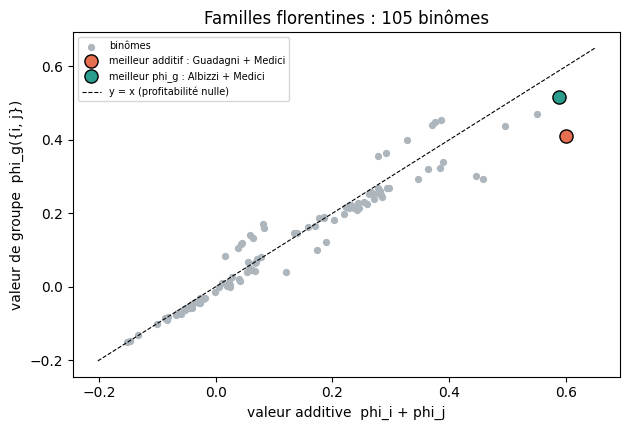

Binômes profitables (au-dessus de y = x) : 29 sur 105


In [12]:
# Code 4.4 - Nuage des 105 binômes : valeur additive contre valeur de groupe.
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(valeur_add, valeur_g, s=18, color="#adb5bd", label="binômes")
k_opt = int(classement[0])
for k, couleur, texte in [(meilleur_add, "#e76f51", "meilleur additif"), (k_opt, "#2a9d8f", "meilleur phi_g")]:
    ax.scatter(valeur_add[k], valeur_g[k], s=90, color=couleur, edgecolors="black", zorder=3,
               label=f"{texte} : {' + '.join(t_flo.names(paires[k]))}")
lims = [min(valeur_add.min(), valeur_g.min()) - 0.05, max(valeur_add.max(), valeur_g.max()) + 0.05]
ax.plot(lims, lims, "--", color="black", linewidth=0.8, label="y = x (profitabilité nulle)")
ax.set_xlabel("valeur additive  phi_i + phi_j")
ax.set_ylabel("valeur de groupe  phi_g({i, j})")
ax.set_title("Familles florentines : 105 binômes")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()
print(f"Binômes profitables (au-dessus de y = x) : {int((valeur_g > valeur_add + 1e-12).sum())} sur {len(paires)}")

### Lecture du résultat : l'ordre global tient, la tête s'inverse

Le nuage suit une tendance croissante très nette, ce qui explique la corrélation de Spearman élevée du code 4.2. La majorité des binômes est sous la diagonale : 29 seulement sur 105 sont profitables (décompte sous la figure), comme dans l'exemple 1 où la fusion coûtait en général. Mais les deux points colorés, à droite du nuage, sont dans le **mauvais ordre** : le point orange (meilleur au sens additif) est plus à droite, le point vert (meilleur au sens de $\varphi^g$) est plus haut. Choisir sur l'axe horizontal, c'est choisir le mauvais binôme.

### Exercice 3 - Connectivité pondérée

Lindelauf et al. (2013) utilisent une variante pondérée du jeu de connectivité : une coalition connexe d'au moins deux joueurs vaut la **somme des poids** de ses membres, $v(S) = \sum_{i \in S} w_i$, et 0 sinon.

- **Étape 1** : construire ce jeu sur le réseau florentin avec $w_i$ = degré de la famille $i$ (nombre d'alliances). On peut réutiliser `jeu_flo.value(S)` pour tester la connexité.
- **Étape 2** : tabuler avec `GroupValueTable`, puis comparer le meilleur binôme exact au binôme des deux meilleurs individus.
- **Étape 3** : le binôme {Albizzi, Medici} reste-t-il optimal ? Expliquer le résultat par le théorème 2.

*Indice* : `CoalitionGame(n, lambda s: ...)` exige $v(\varnothing) = 0$, ce qui est bien le cas ici.

In [13]:
# Exercice 3 : jeu de connectivité pondéré par le degré sur le réseau florentin.
# TODO étudiant : définir les poids, construire le CoalitionGame pondéré,
# tabuler avec GroupValueTable et comparer best_groups(2) au top-2 individuel.

poids = None  # TODO étudiant : np.array des degrés, dans l'ordre de `familles`
meilleur_binome_pondere = None  # TODO étudiant

print("Exercice 3 à compléter : connectivité pondérée (Lindelauf et al. 2013).")

Exercice 3 à compléter : connectivité pondérée (Lindelauf et al. 2013).


## 5. Quand $2^n$ devient hors de portée : l'estimation Monte Carlo

### 5.1 L'estimateur et sa calibration

La tabulation exacte coûte $2^n$ évaluations de $v$ : elle est confortable pour $n = 15$, impossible pour $n = 34$ ($2^{34} \approx 1.7 \times 10^{10}$). Castro, Gómez et Tejada (2009) estiment la valeur de Shapley par échantillonnage d'ordres aléatoires, et l'article procède ainsi pour ses réseaux.

Pour un groupe, l'estimateur est direct. Dans un ordre uniforme des $m$ acteurs du jeu fusionné, le nombre $t$ de prédécesseurs du mandataire est uniforme sur $\{0, \dots, m-1\}$, et l'ensemble $T$ de ces prédécesseurs est un sous-ensemble uniforme de taille $t$ de $N \setminus C$. La moyenne de $v(T \cup C) - v(T)$ est donc un estimateur **sans biais** de $\varphi^g(C)$, et son écart-type empirique divisé par $\sqrt{n_{\text{échantillons}}}$ donne l'erreur-type.

Avant de s'en servir là où l'on ne peut plus vérifier, on le **calibre** là où l'on connaît la réponse : sur le réseau florentin, pour quatre groupes, trois tailles d'échantillon et vingt graines.

In [14]:
# Code 5.1 - Calibration de l'estimateur Monte Carlo contre les valeurs exactes florentines.
groupes_test = [("Medici",), ("Albizzi", "Medici"), ("Guadagni", "Medici"), ("Albizzi", "Guadagni", "Medici")]
tailles = (250, 1000, 4000)
debut = time.perf_counter()
print(f"{'groupe':>26}  {'exact':>6}  " + "  ".join(f"{'n=' + str(s):>17}" for s in tailles))
for groupe in groupes_test:
    membres = [rang[f] for f in groupe]
    exact = t_flo.group_value(membres)
    cellules = []
    for s in tailles:
        erreurs_types, couverts = [], 0
        for graine in range(20):
            est, se = shapley_group_value_monte_carlo(jeu_flo, membres, n_samples=s, seed=graine)
            erreurs_types.append(se)
            couverts += abs(est - exact) < 2 * se
        cellules.append(f"se {np.mean(erreurs_types):.4f} | {couverts:>2}/20")
    print(f"{' + '.join(groupe):>26}  {exact:6.4f}  " + "  ".join(f"{c:>17}" for c in cellules))
print(f"\nDurée totale : {time.perf_counter() - debut:.1f} s  (se = erreur-type moyenne ; k/20 = graines où |estimation - exact| < 2 se)")

                    groupe   exact              n=250             n=1000             n=4000


                    Medici  0.3463  se 0.0308 | 19/20  se 0.0155 | 19/20  se 0.0077 | 20/20


          Albizzi + Medici  0.5161  se 0.0325 | 18/20  se 0.0162 | 19/20  se 0.0081 | 20/20


         Guadagni + Medici  0.4102  se 0.0324 | 20/20  se 0.0161 | 18/20  se 0.0081 | 20/20


Albizzi + Guadagni + Medici  0.6688  se 0.0302 | 18/20  se 0.0151 | 20/20  se 0.0076 | 20/20

Durée totale : 2.6 s  (se = erreur-type moyenne ; k/20 = graines où |estimation - exact| < 2 se)


### Lecture du résultat : l'erreur-type est honnête

Deux propriétés se lisent dans le tableau. D'abord, l'erreur-type **se divise par deux quand l'échantillon est multiplié par quatre** (environ $0.03$, puis $0.015$, puis $0.008$) : c'est la décroissance en $1/\sqrt{n}$ attendue. Ensuite, l'intervalle « estimation $\pm$ 2 erreurs-types » contient la valeur exacte dans 231 des 240 essais (96 %), jamais moins de 18 graines sur 20 par case, conformément au taux nominal d'environ 95 % : l'erreur-type annoncée n'est ni optimiste ni pessimiste.

On peut donc lire une différence entre deux groupes estimés en la rapportant à l'erreur-type de la différence, $\sqrt{se_1^2 + se_2^2}$ pour deux estimations indépendantes. C'est ce qu'on fait maintenant sur un réseau trop grand pour le calcul exact.

### 5.2 Le club de karaté de Zachary

Le **club de karaté de Zachary** (1977) est le réseau d'amitiés des 34 membres d'un club universitaire, observé juste avant sa scission entre l'instructeur (sommet 0) et le président (sommet 33). La table exacte y compterait $2^{34}$ valeurs : `GroupValueTable` refuse de la construire au-delà de 22 joueurs. On estime donc tout par Monte Carlo : les 34 valeurs individuelles (via $\varphi^g(\{i\}) = \varphi_i$), puis les binômes formés parmi les huit meilleurs individus.

In [15]:
# Code 5.2 - Club de karaté : valeurs individuelles et binômes estimés par Monte Carlo.
karate = nx.karate_club_graph()
nk = karate.number_of_nodes()
jeu_k = connectivity_game(nk, list(karate.edges()), [str(i) for i in range(nk)])
print(f"{nk} membres, {karate.number_of_edges()} liens, 2^{nk} = {2 ** nk:.2e} coalitions")

debut = time.perf_counter()
indiv = np.array([shapley_group_value_monte_carlo(jeu_k, [i], n_samples=2000, seed=100 + i) for i in range(nk)])
ordre_k = np.argsort(-indiv[:, 0])
print(f"Valeurs individuelles estimées en {time.perf_counter() - debut:.1f} s ; huit premiers :")
print("  " + ", ".join(f"{int(i)}: {indiv[i, 0]:.3f}±{indiv[i, 1]:.3f}" for i in ordre_k[:8]))

debut = time.perf_counter()
top8 = sorted(int(i) for i in ordre_k[:8])
estim_paires = []
for a, b in combinations(top8, 2):
    est, se = shapley_group_value_monte_carlo(jeu_k, [a, b], n_samples=3000, seed=1000 + 40 * a + b)
    estim_paires.append(((a, b), est, se))
estim_paires.sort(key=lambda r: -r[1])
print(f"\n{len(estim_paires)} binômes estimés en {time.perf_counter() - debut:.1f} s ; cinq premiers :")
for paire, est, se in estim_paires[:5]:
    print(f"  {paire}: phi_g = {est:.3f} ± {se:.3f}")
troisieme = int(ordre_k[2])
paire_03 = tuple(sorted((0, troisieme)))
rang_03, (_, est_03, se_03) = [(r, e) for r, e in enumerate(estim_paires, start=1) if e[0] == paire_03][0]
print(f"Binôme instructeur + troisième individu {paire_03} : phi_g = {est_03:.3f} ± {se_03:.3f}, rang {rang_03} sur {len(estim_paires)}")
top2_k = tuple(sorted(int(i) for i in ordre_k[:2]))
print(f"Binôme des deux meilleurs individus {top2_k} : rang {[p for p, _, _ in estim_paires].index(top2_k) + 1} sur {len(estim_paires)}")

34 membres, 78 liens, 2^34 = 1.72e+10 coalitions


Valeurs individuelles estimées en 1.2 s ; huit premiers :
  0: 0.533±0.011, 33: 0.239±0.010, 32: 0.069±0.006, 31: 0.067±0.006, 2: 0.056±0.005, 6: 0.051±0.006, 5: 0.041±0.005, 29: 0.036±0.005



28 binômes estimés en 1.5 s ; cinq premiers :
  (0, 33): phi_g = 0.679 ± 0.009
  (0, 31): phi_g = 0.629 ± 0.009
  (0, 5): phi_g = 0.583 ± 0.009
  (0, 2): phi_g = 0.579 ± 0.009
  (0, 6): phi_g = 0.570 ± 0.009
Binôme instructeur + troisième individu (0, 32) : phi_g = 0.552 ± 0.009, rang 6 sur 28
Binôme des deux meilleurs individus (0, 33) : rang 1 sur 28


### Lecture du résultat : ici, les deux chefs forment bien le meilleur binôme

Les deux figures du conflit dominent le classement individuel : l'instructeur (0) vaut environ $0.53$ et le président (33) environ $0.24$, loin devant les six suivants (entre $0.036$ et $0.069$). Parmi les binômes estimés, **{0, 33}** arrive en tête : cette fois, le binôme des deux meilleurs individus est aussi le meilleur binôme. C'est un résultat honnête et utile : la valeur de groupe ne contredit pas systématiquement le classement individuel.

Les rangs suivants sont plus instructifs. Ils associent tous l'instructeur à un autre membre, et l'ordre de ces partenaires ne suit pas leur valeur individuelle : le sommet 32, troisième individu, ne forme avec l'instructeur que le sixième binôme (avant-dernière ligne), derrière {0, 5}, dont le partenaire vaut individuellement moins de deux tiers de 32. Les écarts de quelques millièmes entre binômes voisins, comme {0, 5} et {0, 2}, restent en revanche inférieurs à l'erreur-type et ne se lisent pas comme un classement. Le sommet 32 n'est pas voisin de l'instructeur, et dix de ses onze autres voisins sont aussi voisins du président : il est redondant avec 33. La section suivante mesure cette redondance au troisième membre.

32 candidats estimés en 1.3 s ; six meilleurs troisièmes membres :
  31: phi_g({0, 33, 31}) = 0.910 ± 0.006  adjacent à 0 et à 33
   8: phi_g({0, 33, 8}) = 0.820 ± 0.009  adjacent à 0 et à 33
  13: phi_g({0, 33, 13}) = 0.817 ± 0.009  adjacent à 0 et à 33
  19: phi_g({0, 33, 19}) = 0.803 ± 0.009  adjacent à 0 et à 33
   5: phi_g({0, 33, 5}) = 0.732 ± 0.010  
   6: phi_g({0, 33, 6}) = 0.732 ± 0.010  

Troisième meilleur individu : 32, rang 25 sur 32 comme troisième membre
Écart 31 contre 32 : 0.237, soit 19.1 erreurs-types


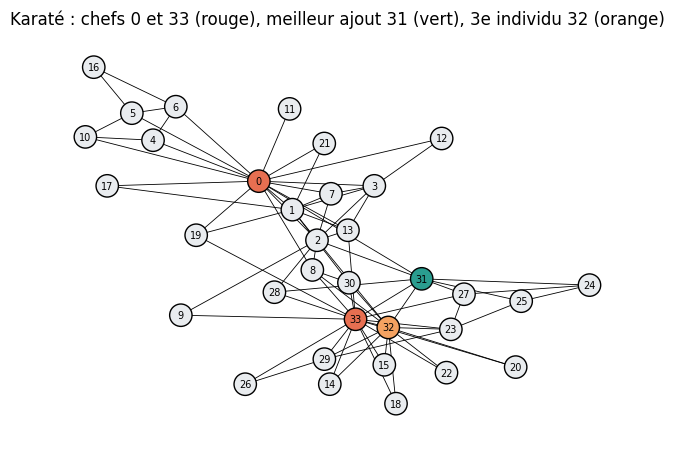

In [16]:
# Code 5.3 - Quel troisième membre ajouter au binôme {0, 33} ? (étape gloutonne estimée)
debut = time.perf_counter()
candidats = [i for i in range(nk) if i not in (0, 33)]
trios = []
for i in candidats:
    est, se = shapley_group_value_monte_carlo(jeu_k, [0, 33, i], n_samples=2000, seed=5000 + i)
    trios.append((i, est, se))
trios.sort(key=lambda r: -r[1])
print(f"{len(candidats)} candidats estimés en {time.perf_counter() - debut:.1f} s ; six meilleurs troisièmes membres :")
for i, est, se in trios[:6]:
    voisin = "adjacent à 0 et à 33" if karate.has_edge(i, 0) and karate.has_edge(i, 33) else ""
    print(f"  {i:>2}: phi_g({{0, 33, {i}}}) = {est:.3f} ± {se:.3f}  {voisin}")

troisieme_individu = int([i for i in ordre_k if int(i) not in (0, 33)][0])
position = [i for i, _, _ in trios].index(troisieme_individu) + 1
(b_i, b_est, b_se), = trios[:1]
t_est, t_se = [(e, s) for i, e, s in trios if i == troisieme_individu][0]
print(f"\nTroisième meilleur individu : {troisieme_individu}, rang {position} sur {len(trios)} comme troisième membre")
print(f"Écart {b_i} contre {troisieme_individu} : {b_est - t_est:.3f}, soit {(b_est - t_est) / np.hypot(b_se, t_se):.1f} erreurs-types")

couleurs = ["#e76f51" if i in (0, 33) else "#2a9d8f" if i == b_i else "#f4a261" if i == troisieme_individu else "#e9ecef"
            for i in karate.nodes()]
fig, ax = plt.subplots(figsize=(6.4, 4.6))
nx.draw_networkx(karate, nx.spring_layout(karate, seed=31), ax=ax, node_color=couleurs, node_size=260,
                 edgecolors="black", font_size=7, width=0.6)
ax.set_title(f"Karaté : chefs 0 et 33 (rouge), meilleur ajout {b_i} (vert), 3e individu {troisieme_individu} (orange)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Lecture du résultat : le meilleur renfort est un pont, pas une vedette

Le meilleur troisième membre estimé est un membre **adjacent aux deux chefs** : il relie les deux camps, et c'est précisément ce qui manque au binôme {0, 33}, dont les membres ne sont pas voisins. Les quatre premiers candidats sont exactement les quatre membres voisins à la fois de 0 et de 33 (mention en fin de ligne) ; les deux suivants affichés, 5 et 6, voisins du seul instructeur, décrochent d'environ $0.07$. Le troisième meilleur individu, lui, tombe loin dans le classement des troisièmes membres : il apporte au groupe ce que le président lui apporte déjà.

L'écart entre le meilleur ajout et le troisième individu vaut près de vingt erreurs-types (dernière ligne avant la figure) : ce n'est pas du bruit d'échantillonnage. Sur la figure, le nœud vert est relié aux deux nœuds rouges, alors que le nœud orange, relié au seul président, se confond presque avec lui : il partage dix de ses onze autres voisins. C'est le même mécanisme que le pont 5 de l'exemple 1 et que les Albizzi à Florence, cette fois établi sur un réseau où aucun calcul exact n'était possible.

**Portée** : il s'agit d'une étape gloutonne conditionnée à {0, 33}. Le meilleur trio global exigerait d'estimer les $\binom{34}{3} = 5\,984$ trios ; rien ne garantit ici qu'il contienne {0, 33}.

### Exercice 4 (bonus) - Comparer deux groupes avec des nombres aléatoires communs

Pour comparer deux trios $\{0, 33, a\}$ et $\{0, 33, b\}$, les deux estimations du code 5.3 sont indépendantes, et l'erreur-type de leur différence cumule les deux variances. Une technique classique réduit ce bruit : tirer **les mêmes** ordres aléatoires pour les deux groupes et estimer directement la différence.

- **Étape 1** : écrire une fonction qui tire $t$ et le sous-ensemble $T$ **une seule fois** parmi les joueurs hors de $\{0, 33, a, b\}$, puis évalue la contribution des deux groupes sur ce même tirage. Attention : les deux jeux fusionnés n'ont pas le même ensemble de joueurs extérieurs ; une façon correcte de faire consiste à estimer $\varphi^g(\{0,33,a\}) - \varphi^g(\{0,33,b\})$ par le théorème 2 appliqué à $C = \{0, 33\}$.
- **Étape 2** : comparer l'erreur-type obtenue à $\sqrt{se_a^2 + se_b^2}$ pour le même nombre d'échantillons.
- **Étape 3** : combien d'échantillons faut-il pour séparer à 3 erreurs-types les deux meilleurs candidats du code 5.3 ?

In [17]:
# Exercice 4 (bonus) : estimation de la différence entre deux trios par nombres aléatoires communs.
# TODO étudiant : implémenter l'estimateur apparié et comparer les erreurs-types.

erreur_type_appariee = None  # TODO étudiant
erreur_type_independante = None  # TODO étudiant

print("Exercice 4 (bonus) à compléter : nombres aléatoires communs.")

Exercice 4 (bonus) à compléter : nombres aléatoires communs.


## Résumé

1. **Définition** (section 1) : la valeur de Shapley de groupe $\varphi^g(C)$ est la valeur de Shapley du mandataire du groupe dans le jeu fusionné de Lehrer. Elle diffère de la valeur additive par le seul axiome G-SPB : dans un marchandage pur, un groupe pèse **une voix** ($1/(n-c+1)$), pas **$c$ voix** ($c/n$).
2. **Reproduction exacte** (section 2) : l'exemple 1 de l'article est reproduit en fractions ($360\,\varphi = -8, 139, 130$ ; $\varphi^g(\{4,6\}) = 1/2$ ; $\varphi^g(\{4,5\}) = 187/280$) ainsi que les quatre termes de sa décomposition par le théorème 2. Le meilleur binôme associe un centre et le pont, pas les deux centres.
3. **Complémentarité** (section 3) : la complémentarité $\psi$ est positive sur toutes les arêtes du graphe et négative sur la plupart des paires éloignées ; seuls des binômes adjacents sont profitables, mais les deux meilleurs binômes ne le sont pas. Valeur, complémentarité et profitabilité sont trois grandeurs distinctes.
4. **Florence** (section 4) : sur le réseau de Padgett, calcul exact sur $2^{15}$ coalitions. Le meilleur binôme est {Albizzi, Medici} (0.516) ; le binôme des deux meilleurs individus {Guadagni, Medici} n'est que septième (0.410), alors que la valeur additive les classe dans l'ordre inverse. L'écart disparaît pour $k = 3$.
5. **Monte Carlo** (section 5) : l'estimateur est calibré (erreur-type en $1/\sqrt{n}$, couverture proche du nominal). Sur le club de karaté ($2^{34}$ coalitions), les deux chefs forment bien le meilleur binôme, mais le meilleur troisième membre est un pont entre eux, pas le troisième meilleur individu.

La leçon générale : **classer des individus ne classe pas des groupes**. Quand les agents sont redondants ou complémentaires, il faut évaluer le groupe comme une unité, et le théorème 2 dit exactement quelle information le classement individuel laisse de côté.

## Références

- **Flores R., Molina E., Tejada J. (2019)**. Evaluating groups with the generalized Shapley value. *4OR* 17(2):141-172. doi:10.1007/s10288-018-0380-8. Article distillé : définition 2, théorèmes 1 et 2, proposition 1, exemple 1.
- **Marichal J.-L., Kojadinovic I., Fujimoto K. (2007)**. Axiomatic characterizations of generalized values. *Discrete Applied Mathematics* 155:26-43. Valeur de Shapley généralisée.
- **Lehrer E. (1988)**. An axiomatization of the Banzhaf value. *International Journal of Game Theory* 17:89-99. Jeu fusionné.
- **Amer R., Gimenez J. M. (2004)**. A connectivity game for graphs. *Mathematical Methods of Operations Research* 60:453-470.
- **Castro J., Gómez D., Tejada J. (2009)**. Polynomial calculation of the Shapley value based on sampling. *Computers & Operations Research* 36:1726-1730.
- **Derks J., Tijs S. (2000)**. On merge properties of the Shapley value. *International Game Theory Review* 2:249-257.
- **Segal I. (2003)**. Collusion, exclusion and inclusion in random-order bargaining. *Review of Economic Studies* 70:439-460.
- **Grabisch M., Roubens M. (1999)**. An axiomatic approach to the concept of interaction among players in cooperative games. *International Journal of Game Theory* 28:547-565.
- **Lindelauf R., Hamers H. J. M., Husslage B. G. M. (2013)**. Cooperative game theoretic centrality analysis of terrorist networks. *European Journal of Operational Research* 229:230-238. Application d'origine de l'article, non reproduite ici.
- **Padgett J. F., Ansell C. K. (1993)**. Robust action and the rise of the Medici, 1400-1434. *American Journal of Sociology* 98(6):1259-1319.
- **Zachary W. W. (1977)**. An information flow model for conflict and fission in small groups. *Journal of Anthropological Research* 33(4):452-473.
- **Dépôt** : `cooperative_games/group_value.py` (implémentation) et `tests/test_group_value.py` (valeurs publiées, axiomes, théorème 2) ; `GameTheory-15-CooperativeGames.ipynb` (valeur de Shapley individuelle) ; `GameTheory-15d-Mobius-Coalitions.ipynb` (dividendes de Harsanyi).